# Dubins3D — CBF / Hand-CBF / Duality CBF

Experiments with CBF safety filters on the Dubins 3D car (state: x, y, θ; control: yaw rate ω).
Obstacle at the origin; nominal policy steers toward a goal at (2, 0).

In [41]:
import functools as ft
import sys
sys.path.insert(0, '../../src')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
%matplotlib inline

import flax.linen as nn
import optax

from mrncbf.dyn.dubins3d_avoid import Dubins3DAvoid
from mrncbf.qp.min_norm_cbf import min_norm_cbf, gcbf_qp, rcbf_qp_linear, compute_rcbf_gammas
from mrncbf.utils.jax_utils import jax2np

jax.config.update("jax_enable_x64", False)

task = Dubins3DAvoid()

# ── Simulation constants ──────────────────────────────────────────────────────
DT = 0.05   # finer than class DT=0.1 (Euler steps; 10% of obstacle radius per step)
T  = 75    # steps → 10 s

# ── QP / CBF constants ────────────────────────────────────────────────────────
ALPHA_QP = 1.0          # CBF decay rate α
V_SHIFT  = 0.0          # optional barrier shift
u_lb     = jnp.array([-1.0])
u_ub     = jnp.array([ 1.0])
BASE_KEY = jax.random.PRNGKey(42)

# ── HOCBF alpha — shared by rollouts and the MC filter cell ──────────────────
hocbf_alpha = 1.0   # change here; re-run this cell + later cells to propagate

# ── Noise for duality CBF demo ────────────────────────────────────────────────
# STATE_EPS_DUAL = jnp.array([0.1, 0.7, 0.005])   # x, y, theta (m, m, rad)
# STATE_EPS_DUAL = jnp.array([0.1, 0.1, 0.001])
STATE_EPS_DUAL = jnp.array([0.1, 0.3, 0.001])

print(f"Task: nx={task.NX}, nu={task.NU}, umax={task.umax:.3f} rad/s")
print(f"Obstacle: center={tuple(float(v) for v in task.pos_obs)}, r={task.radius_obs}")
print(f"DT={DT}s, T={T} steps ({T*DT:.1f}s total)")


Task: nx=3, nu=1, umax=0.785 rad/s
Obstacle: center=(0.0, 0.0), r=0.5
DT=0.05s, T=75 steps (3.8s total)


## Task verification

Check that the dynamics and safety constraint look correct.

Equilibrium state  x0 = [0. 0. 0.]
Drift  f(x0)          = [1. 0. 0.]  (vel=1.0 m/s eastward at θ=0)
Input  G(x0)          = [0.         0.         0.78539816]
h_components(x0)      = [0.4934082]  (obstacle dist-r = -0.493 m)
handcbf_B(x0, α=1.0) = [nan]


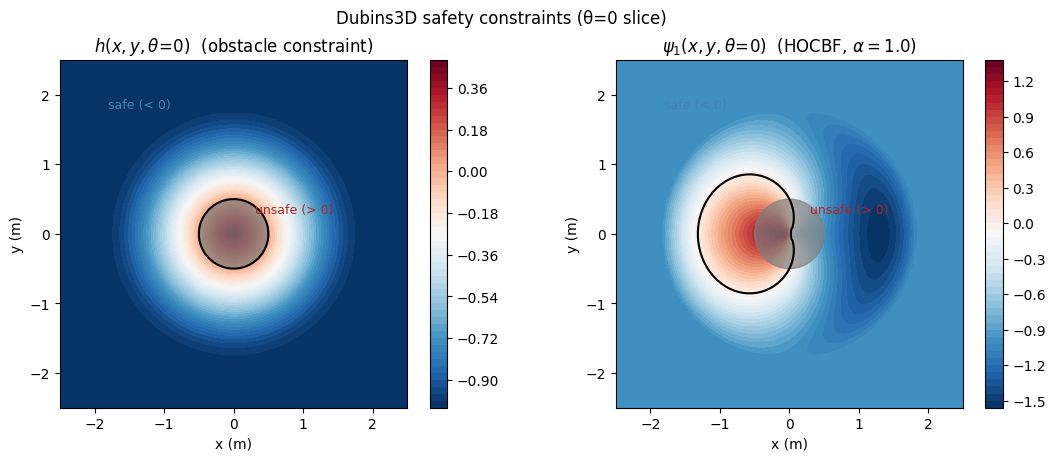

In [42]:
x0 = jnp.array(task.eq_state())   # (0, 0, 0)
f0 = task.f(x0)
G0 = task.G(x0)
h0 = task.h_components(x0)
B0 = task.handcbf_B(x0, hocbf_alpha)

print(f"Equilibrium state  x0 = {jax2np(x0)}")
print(f"Drift  f(x0)          = {jax2np(f0)}  (vel={task.VEL} m/s eastward at θ=0)")
print(f"Input  G(x0)          = {jax2np(G0).flatten()}")
print(f"h_components(x0)      = {jax2np(h0)}  (obstacle dist-r = {-float(h0[0]):.3f} m)")
print(f"handcbf_B(x0, α={hocbf_alpha}) = {jax2np(B0)}")

# ── Visualise h and ψ₁ over the xy plane (θ=0) ───────────────────────────────
n = 80
xs_g = np.linspace(-2.5, 2.5, n)
ys_g = np.linspace(-2.5, 2.5, n)
XX, YY = np.meshgrid(xs_g, ys_g)
x_grid = jnp.array(np.stack([XX.ravel(), YY.ravel(), np.zeros(n*n)], axis=1))

nh = task.nh
# vmap returns (n*n, nh); reshape to (n, n, nh) then index [:,:,0]
h_grid = jax2np(jax.vmap(task.h_components)(x_grid)).reshape(n, n, nh)
B_grid = jax2np(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x_grid)).reshape(n, n, nh)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), layout='constrained')
for ax, Z, title in zip(axes,
                         [h_grid[:,:,0], B_grid[:,:,0]],
                         [r'$h(x,y,\theta\!=\!0)$  (obstacle constraint)',
                          rf'$\psi_1(x,y,\theta\!=\!0)$  (HOCBF, $\alpha={hocbf_alpha}$)']):
    cm = ax.contourf(XX, YY, Z, levels=50, cmap='RdBu_r')
    ax.contour(XX, YY, Z, levels=[0.0], colors='k', linewidths=1.5)
    fig.colorbar(cm, ax=ax)
    obs = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                     task.radius_obs, color='gray', alpha=0.7)
    ax.add_patch(obs)
    ax.set(title=title, xlabel='x (m)', ylabel='y (m)', aspect='equal',
           xlim=(-2.5, 2.5), ylim=(-2.5, 2.5))
    ax.annotate('safe (< 0)', xy=(-1.8, 1.8), color='steelblue', fontsize=9)
    ax.annotate('unsafe (> 0)', xy=(0.3, 0.3), color='firebrick', fontsize=9)
plt.suptitle('Dubins3D safety constraints (θ=0 slice)')
plt.show()


## Nominal-policy rollouts

The nominal `nom_pol_goto` steers toward (2, 0) and drives straight through the obstacle when unconstrained.

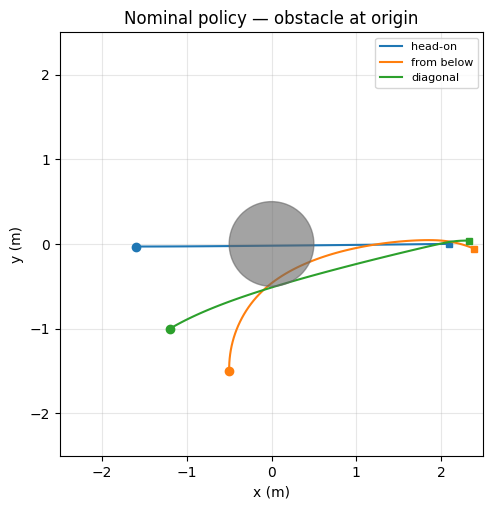

In [43]:
# ── Rollout helper ────────────────────────────────────────────────────────────
def _make_rollout(step_fn):
    """Wrap step_fn(x, step_idx) → (x_next, x) into a JIT-compiled rollout."""
    def rollout(x0):
        _, xs = jax.lax.scan(step_fn, x0, jnp.arange(T))
        return jnp.concatenate([x0[None], xs], axis=0)   # (T+1, nx)
    return jax.jit(rollout)

# ── Nominal step (no noise, no CBF) ──────────────────────────────────────────
def _nom_step(x, step_idx):
    u = task.nom_pol_goto(x)
    return x + DT * task.xdot(x, u), x

rollout_nom = _make_rollout(_nom_step)

# ── A few challenging initial conditions ─────────────────────────────────────
x_ics = {
    'head-on':   jnp.array([-1.6,  -0.03,  0.0]),           # east, straight at obstacle
    'from below':jnp.array([-0.5, -1.5,  np.pi/2]),        # north from below
    'diagonal':  jnp.array([-1.2, -1.0,  np.pi/6]),        # NE approach
    'head-on+':  jnp.array([-1.6,  0.05,  0.0]),           # east, straight at obstacle, other side
}

# ── Plot nominal trajectories ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5.5, 5.5))
obs_patch = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.4', alpha=0.6, zorder=3)
ax.add_patch(obs_patch)
colors = ['C0', 'C1', 'C2']
for (name, x0), col in zip(x_ics.items(), colors):
    xs = jax2np(rollout_nom(x0))          # (T+1, 3)
    ax.plot(xs[:, 0], xs[:, 1], color=col, lw=1.5, label=name)
    ax.plot(*xs[0, :2], 'o', color=col, ms=6)
    ax.plot(*xs[-1, :2], 's', color=col, ms=5)
ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect='equal',
       xlabel='x (m)', ylabel='y (m)', title='Nominal policy — obstacle at origin')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
plt.show()


## Hand-CBF safety filter

Apply the HOCBF `handcbf_B` (ψ₁ = L_f h + α h) via a min-norm QP.  Control appears in ψ̇₁, so the QP is feasible (relative degree 2 → 1 for ψ₁).

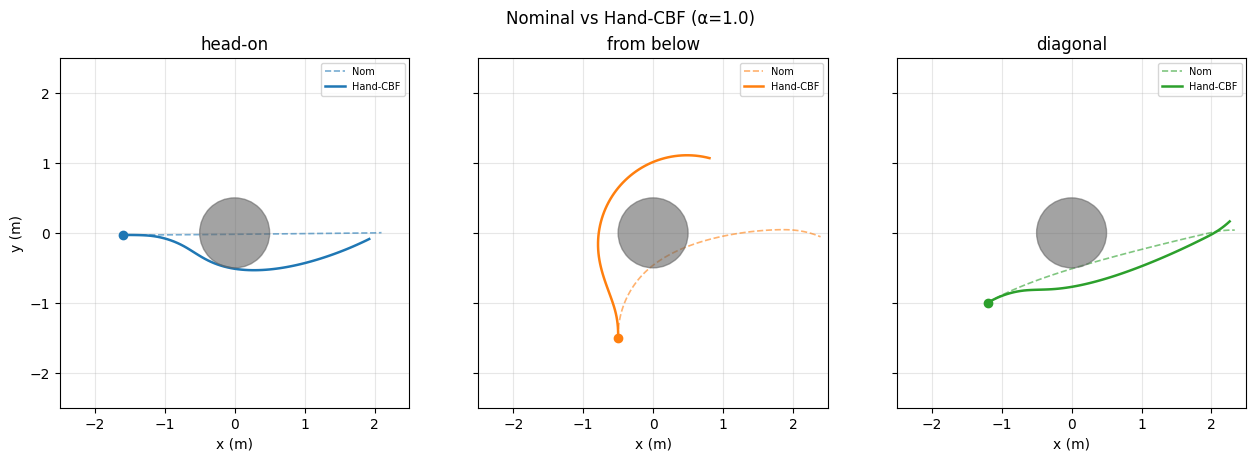

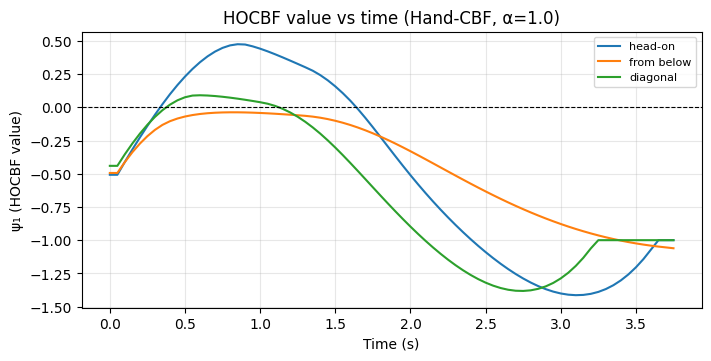

In [44]:
# ── Hand-CBF step (perfect state estimate) ────────────────────────────────────
def _handcbf_step(x, step_idx):
    u_nom = task.nom_pol_goto(x)
    h_B   = task.handcbf_B(x, hocbf_alpha) + V_SHIFT
    hx_B  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_B,
                            task.f(x), task.G(x), u_nom, relax_eps2=0.1)
    return x + DT * task.xdot(x, u), x

rollout_handcbf = _make_rollout(_handcbf_step)

# ── Compare nominal vs hand-CBF for each IC ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), layout='constrained', sharey=True)
for ax, (name, x0), col in zip(axes, x_ics.items(), colors):
    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.4', alpha=0.6, zorder=3)
    ax.add_patch(obs_p)
    xs_nom = jax2np(rollout_nom(x0))
    xs_cbf = jax2np(rollout_handcbf(x0))
    ax.plot(xs_nom[:, 0], xs_nom[:, 1], '--', color=col, lw=1.2, alpha=0.6, label='Nom')
    ax.plot(xs_cbf[:, 0], xs_cbf[:, 1],       color=col, lw=1.8,            label='Hand-CBF')
    ax.plot(*xs_nom[0, :2], 'o', color=col, ms=6)
    ax.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect='equal',
           xlabel='x (m)', title=name)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)
axes[0].set_ylabel('y (m)')
fig.suptitle(f'Nominal vs Hand-CBF (α={hocbf_alpha})')
plt.show()

# ── CBF value over time ───────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 3.5), layout='constrained')
t_arr = np.arange(T + 1) * DT
h_vmap = jax.jit(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha)))
for (name, x0), col in zip(x_ics.items(), colors):
    xs_cbf = jax2np(rollout_handcbf(x0))
    psi1   = jax2np(h_vmap(jnp.array(xs_cbf)))[:, 0]
    ax.plot(t_arr, psi1, color=col, lw=1.5, label=name)
ax.axhline(0, color='k', lw=0.8, ls='--')
ax.set(xlabel='Time (s)', ylabel='ψ₁ (HOCBF value)',
       title=f'HOCBF value vs time (Hand-CBF, α={hocbf_alpha})')
ax.legend(fontsize=8); ax.grid(alpha=0.3)
plt.show()


## Duality CBF — robust to measurement noise

With noisy state estimates the naive CBF may apply the wrong control.  The duality CBF finds the worst-case state inside the uncertainty box for each (constraint, direction) pair and passes all of them to a single QP.

In [45]:
# ── Constant bias noise model ─────────────────────────────────────────────────
# A single bias is sampled once per trajectory and added to every state estimate.
# More realistic than i.i.d. per-step noise for sensor offsets / GPS drift.
def _sample_bias(key):
    return jax.random.uniform(key, (task.NX,), minval=-STATE_EPS_DUAL, maxval=STATE_EPS_DUAL)

# ── Projected gradient ascent over a box ─────────────────────────────────────
def proj_grad_max_box(scalar_fn, lo, hi, n_restarts, n_steps, lr, key):
    """Maximise scalar_fn over [lo, hi] via projected gradient ascent."""
    x0s = lo[None] + jax.random.uniform(key, (n_restarts, lo.shape[0])) * (hi - lo)
    def run_one(x0):
        def step(x, _):
            g = jax.grad(scalar_fn)(x)
            return jnp.clip(x + lr * g, lo, hi), None
        x_star, _ = jax.lax.scan(step, x0, None, length=n_steps)
        return scalar_fn(x_star), x_star
    vals, xs = jax.vmap(run_one)(x0s)
    best = jnp.argmax(vals)
    return vals[best], xs[best]

# ── CBF ingredients: h, Lf h, LG h ───────────────────────────────────────────
def _cbf_ingredients(x):
    h  = task.handcbf_B(x, hocbf_alpha)
    hx = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x)
    return h, hx @ task.f(x), hx @ task.G(x)

# ── Dual directions on S^1 (nu+1 = 2 for Dubins) ─────────────────────────────
N_PLANES_DUAL = 2
angles        = np.linspace(0, 2*np.pi, N_PLANES_DUAL, endpoint=False)
_DUAL_DIRS    = np.stack([np.cos(angles), np.sin(angles)], axis=1).astype(np.float32)

_NH = task.nh   # 1
_nu = task.nu   # 1

# ── Step functions — carry = (x_true, bias) ───────────────────────────────────
# bias is sampled once before the rollout; xhat = x_true + bias every step.

def _nom_noisy_step(carry, step_idx):
    x, bias = carry
    xhat = x + bias
    u    = task.nom_pol_goto(xhat)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

def _cbf_noisy_step(carry, step_idx):
    """Naive hand-CBF applied at biased estimate — no bias awareness."""
    x, bias = carry
    xhat  = x + bias
    h_B   = task.handcbf_B(xhat, hocbf_alpha) + V_SHIFT
    hx_B  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(xhat)
    u_nom = task.nom_pol_goto(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_B,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

def _duality_step(carry, step_idx):
    """Duality CBF: worst-case over uncertainty box centred on biased estimate."""
    x, bias = carry
    xhat  = x + bias
    lo    = xhat - STATE_EPS_DUAL
    hi    = xhat + STATE_EPS_DUAL
    u_nom = task.nom_pol_goto(xhat)

    # Random restarts for proj-grad — keyed by step so they vary each step
    opt_key  = jax.random.fold_in(BASE_KEY, step_idx)
    all_keys = jax.random.split(opt_key, N_PLANES_DUAL)

    def _worst_one(d_vec, k_j):
        def _obj(xi):
            h, Lf_h, LG_h = _cbf_ingredients(xi)
            return d_vec[0] * LG_h[0, 0] + d_vec[1] * (Lf_h[0] + ALPHA_QP * h[0])
        _, x_star = proj_grad_max_box(_obj, lo, hi, n_restarts=4, n_steps=25, lr=0.05, key=k_j)
        h_s, Lf_s, LG_s = _cbf_ingredients(x_star)
        return h_s[0], Lf_s[0], LG_s[0]

    h_all, Lf_all, LG_all = jax.vmap(_worst_one)(jnp.array(_DUAL_DIRS), all_keys)
    u, _, _ = gcbf_qp(ALPHA_QP, u_lb, u_ub, h_all, Lf_all, LG_all, u_nom, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

# ── Rollout wrapper: rollout(x0, bias) → (xs_full, xhats) ────────────────────
def _make_noisy_rollout(step_fn):
    def rollout(x0, bias):
        _, (xs, xhats) = jax.lax.scan(step_fn, (x0, bias), jnp.arange(T))
        xs_full = jnp.concatenate([x0[None], xs], axis=0)
        return xs_full, xhats
    return jax.jit(rollout)

rollout_nom_noisy = _make_noisy_rollout(_nom_noisy_step)
rollout_cbf_noisy = _make_noisy_rollout(_cbf_noisy_step)
rollout_duality   = _make_noisy_rollout(_duality_step)

print(f"Duality: {_NH} constraint x {N_PLANES_DUAL} directions = {_NH*N_PLANES_DUAL} pairs")
print("Compiling...")
x_test    = jnp.array(list(x_ics.values())[0])
bias_test = _sample_bias(BASE_KEY)
rollout_nom_noisy(x_test, bias_test); print("  nom+noise done")
rollout_cbf_noisy(x_test, bias_test); print("  CBF+noise done")
rollout_duality(x_test, bias_test);   print("  duality done")
# ── R-CBF-QP step function ────────────────────────────────────────────────────
# Samples N random states from the uncertainty box, computes gammas that bound
# the worst-case CBF constraint error, then solves a tightened QP.
N_RCBF_SAMPLES = 20

def _rcbf_step(carry, step_idx):
    """R-CBF-QP: sample-based tightening over the uncertainty box."""
    x, bias = carry
    xhat = x + bias
    lo   = xhat - STATE_EPS_DUAL
    hi   = xhat + STATE_EPS_DUAL

    samp_key = jax.random.fold_in(BASE_KEY, step_idx)
    x_pert   = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, task.NX)) * (hi - lo)

    _h_fn  = lambda xi: task.handcbf_B(xi, hocbf_alpha)
    _hx_fn = jax.jacobian(_h_fn)

    h_V_nom   = _h_fn(xhat)
    hx_Vx_nom = _hx_fn(xhat)
    u_nom     = task.nom_pol_goto(xhat)

    h_V_pert   = jax.vmap(_h_fn)(x_pert)                  # (N, nh)
    hx_Vx_pert = jax.vmap(_hx_fn)(x_pert)                 # (N, nh, nx)
    f_pert     = jax.vmap(task.f)(x_pert)                  # (N, nx)
    G_pert     = jax.vmap(task.G)(x_pert)                  # (N, nx, nu)
    u_nom_pert = jax.vmap(task.nom_pol_goto)(x_pert)       # (N, nu)

    gamma1, gamma2 = compute_rcbf_gammas(
        alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
        h_V_nom=h_V_nom, hx_Vx_nom=hx_Vx_nom,
        f_nom=task.f(xhat), G_nom=task.G(xhat), u_nom_base=u_nom,
        h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
        f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert,
        n_grid=100,
    )
    # gamma1, gamma2 = 1.0, 1.0
    u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
                              h_V_nom, hx_Vx_nom, task.f(xhat), task.G(xhat), u_nom,
                              gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

rollout_rcbf = _make_noisy_rollout(_rcbf_step)
rollout_rcbf(x_test, bias_test)
print("  R-CBF-QP done")
# ── phi + R-CBF-QP hybrid step ────────────────────────────────────────────────
# Combines both corrections: phi tightens the barrier at xhat (worst-case Lf h
# offset), then R-CBF-QP gammas additionally tighten for control sensitivity
# across the uncertainty box.

# def _phi_rcbf_step(carry, step_idx):
#     x, bias = carry
#     xhat = x + bias
#     lo   = xhat - STATE_EPS_DUAL
#     hi   = xhat + STATE_EPS_DUAL

#     samp_key = jax.random.fold_in(BASE_KEY, step_idx)
#     x_pert   = lo[None] + jax.random.uniform(samp_key, (N_RCBF_SAMPLES, task.NX)) * (hi - lo)

#     _h_fn  = lambda xi: task.handcbf_B(xi, hocbf_alpha)
#     _hx_fn = jax.jacobian(_h_fn)

#     h_V_nom   = _h_fn(xhat)
#     phi       = phi_net.apply({'params': _phi_params_frozen}, xhat)   # (nh,)
#     h_tight   = h_V_nom + phi / ALPHA_QP                              # phi-tightened barrier
#     hx_Vx_nom = _hx_fn(xhat)
#     u_nom     = task.nom_pol_goto(xhat)

#     h_V_pert   = jax.vmap(_h_fn)(x_pert)
#     hx_Vx_pert = jax.vmap(_hx_fn)(x_pert)
#     f_pert     = jax.vmap(task.f)(x_pert)
#     G_pert     = jax.vmap(task.G)(x_pert)
#     u_nom_pert = jax.vmap(task.nom_pol_goto)(x_pert)

#     gamma1, gamma2 = compute_rcbf_gammas(
#         alpha=ALPHA_QP, u_lb=u_lb, u_ub=u_ub,
#         h_V_nom=h_tight, hx_Vx_nom=hx_Vx_nom,
#         f_nom=task.f(xhat), G_nom=task.G(xhat), u_nom_base=u_nom,
#         h_V_pert=h_V_pert, hx_Vx_pert=hx_Vx_pert,
#         f_pert=f_pert, G_pert=G_pert, u_nom_pert=u_nom_pert,
#         n_grid=50,
#     )
#     u, _, _ = rcbf_qp_linear(ALPHA_QP, u_lb, u_ub,
#                               h_tight, hx_Vx_nom, task.f(xhat), task.G(xhat), u_nom,
#                               gamma1=gamma1, gamma2=gamma2, relax_eps2=0.1)
#     return (x + DT * task.xdot(x, u), bias), (x, xhat)

# rollout_phi_rcbf = _make_noisy_rollout(_phi_rcbf_step)
# rollout_phi_rcbf(x_test, bias_test)
# print("  phi+RCBF done")


Duality: 1 constraint x 2 directions = 2 pairs
Compiling...
  nom+noise done
  CBF+noise done
  duality done
  R-CBF-QP done


## φ learning: amortising the duality optimisation

The duality CBF runs `proj_grad_max_box` at every timestep — expensive at ~10 s per trajectory.
We can **amortise** this by learning a small correction network φ(x̂) that predicts, for each
constraint *i*, the worst-case increase in (L_f h_i + α h_i) over the uncertainty box:

$$\phi_i(\hat x) \approx \max_{x \in [\hat x - \varepsilon,\,\hat x + \varepsilon]}
\bigl(L_f h_i(x) + \alpha\, h_i(x)\bigr) - \bigl(L_f h_i(\hat x) + \alpha\, h_i(\hat x)\bigr)$$

At runtime the φ-CBF simply tightens the barrier: $h_i^{\text{tight}} = h_i(\hat x) + \phi_i(\hat x)/\alpha$,
replacing the online optimisation with a single MLP forward pass.


Computing phi labels for training set...
Computing phi labels for test set...
Label stats  mean=0.2523  std=0.5279  max=5.0000
Fraction non-zero: 39.95%


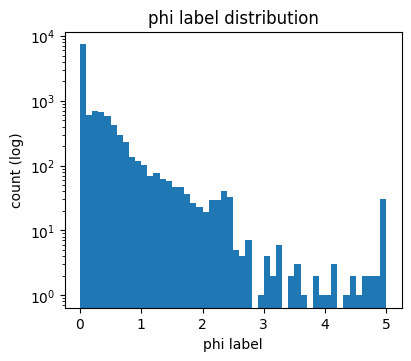

In [46]:
# ── φ label oracle: worst-case correction over uncertainty box ────────────────
PHI_MAX = 5.0   # cap labels against outliers near obstacle boundary

@ft.partial(jax.jit, static_argnames=('n_restarts', 'n_steps'))
def phi_true_fn(xhat, key, n_restarts=4, n_steps=30, lr=0.05):
    """φ_i(x̂) = max_{x in box} (Lf h_i + α h_i)(x) - (Lf h_i + α h_i)(x̂), clipped ≥ 0."""
    lo = xhat - STATE_EPS_DUAL
    hi = xhat + STATE_EPS_DUAL

    h_nom   = task.handcbf_B(xhat, hocbf_alpha)
    Lf_nom  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(xhat) @ task.f(xhat)
    nom_val = Lf_nom + ALPHA_QP * h_nom   # (nh,)

    def worst_i(i, k):
        def obj(x):
            h  = task.handcbf_B(x, hocbf_alpha)
            Lf = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x) @ task.f(x)
            return (Lf + ALPHA_QP * h)[i]
        _, x_wc  = proj_grad_max_box(obj, lo, hi, n_restarts, n_steps, lr, k)
        h_wc  = task.handcbf_B(x_wc, hocbf_alpha)
        Lf_wc = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(x_wc) @ task.f(x_wc)
        delta = (Lf_wc + ALPHA_QP * h_wc)[i] - nom_val[i]
        return jnp.clip(delta, 0.0, PHI_MAX)

    keys = jax.random.split(key, _NH)
    return jax.vmap(worst_i)(jnp.arange(_NH), keys)

# ── Generate training / test datasets ─────────────────────────────────────────
# Sample x̂ uniformly over the full state space. Points far from the obstacle
# will have φ ≈ 0; the network will learn to be non-zero only near the boundary.
lb = jnp.array(task.train_bounds()[0])   # (-2.5, -2.5, -π)
ub = jnp.array(task.train_bounds()[1])   # ( 2.5,  2.5,  π)

N_TRAIN, N_TEST = 12000, 3000
rng_phi         = jax.random.PRNGKey(7)
rng_phi, rng_tr, rng_te = jax.random.split(rng_phi, 3)

xhat_train = lb + jax.random.uniform(rng_tr, (N_TRAIN, task.NX)) * (ub - lb)
xhat_test  = lb + jax.random.uniform(rng_te, (N_TEST,  task.NX)) * (ub - lb)

keys_tr = jax.random.split(rng_phi,              N_TRAIN)
keys_te = jax.random.split(jax.random.PRNGKey(99), N_TEST)

print('Computing phi labels for training set...')
phi_train = jax.vmap(phi_true_fn)(xhat_train, keys_tr)   # (N_TRAIN, nh)
print('Computing phi labels for test set...')
phi_test  = jax.vmap(phi_true_fn)(xhat_test,  keys_te)

phi_tr_np = jax2np(phi_train)
print(f'Label stats  mean={phi_tr_np.mean():.4f}  std={phi_tr_np.std():.4f}'
      f'  max={phi_tr_np.max():.4f}')
print(f'Fraction non-zero: {(phi_tr_np > 0).mean():.2%}')

# ── Quick sanity scatter: predicted vs oracle for a handful of test points ────
fig, ax = plt.subplots(figsize=(4, 3.5), layout='constrained')
ax.scatter(jax2np(phi_test[:200, 0]), phi_tr_np[:200, 0] if _NH > 1 else
           jax2np(phi_true_fn(xhat_test[0], keys_te[0]))[0] * np.ones(200),
           s=6, alpha=0.5)
# (just visualise label distribution via histogram)
ax.cla()
ax.hist(phi_tr_np.ravel(), bins=50, log=True)
ax.set(xlabel='phi label', ylabel='count (log)', title='phi label distribution')
plt.show()


PhiNet: 1217 parameters  (input=3, output=1)
  Epoch 100  train_loss=1.668e-01  val_mse=1.384e-01
  Epoch 200  train_loss=6.884e-02  val_mse=1.067e-01
  Epoch 300  train_loss=4.998e-02  val_mse=9.654e-02
  Epoch 400  train_loss=4.588e-02  val_mse=9.213e-02
  Epoch 500  train_loss=3.133e-02  val_mse=8.996e-02


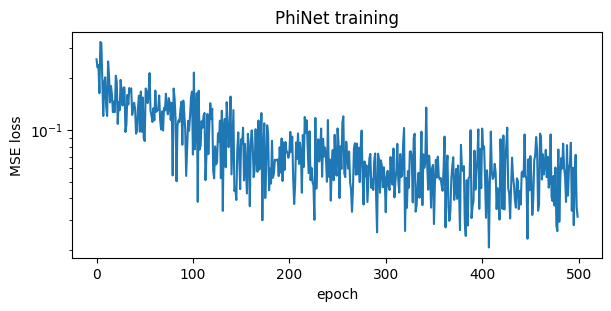

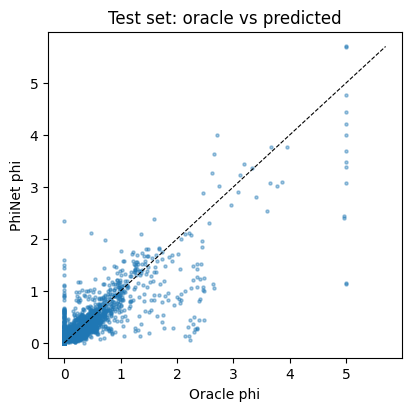

phi-CBF compiled.


In [47]:
# ── PhiNet definition ─────────────────────────────────────────────────────────
class PhiNet(nn.Module):
    hidden_dims: tuple = (32, 32)
    n_constraints: int = _NH

    @nn.compact
    def __call__(self, x):
        h = x
        for d in self.hidden_dims:
            h = nn.tanh(nn.Dense(d)(h))
        return nn.softplus(nn.Dense(self.n_constraints)(h))   # phi >= 0

phi_net    = PhiNet()
phi_params = phi_net.init(jax.random.PRNGKey(0), jnp.zeros(task.NX))['params']
n_params   = sum(p.size for p in jax.tree_util.tree_leaves(phi_params))
print(f'PhiNet: {n_params} parameters  (input={task.NX}, output={_NH})')

optimizer = optax.adam(3e-3)
opt_state = optimizer.init(phi_params)

BATCH_SIZE = 256
N_EPOCHS   = 500

@jax.jit
def train_step(params, opt_state, xb, phi_b):
    def loss_fn(p):
        pred = jax.vmap(lambda x: phi_net.apply({'params': p}, x))(xb)
        return jnp.mean((pred - phi_b) ** 2)
    loss, grads = jax.value_and_grad(loss_fn)(params)
    updates, new_opt = optimizer.update(grads, opt_state, params)
    return optax.apply_updates(params, updates), new_opt, loss

rng_ep = jax.random.PRNGKey(42)
losses = []
for epoch in range(N_EPOCHS):
    rng_ep, rng_shuf = jax.random.split(rng_ep)
    perm = jax.random.permutation(rng_shuf, N_TRAIN)
    for b in range(0, N_TRAIN, BATCH_SIZE):
        idx  = perm[b : b + BATCH_SIZE]
        phi_params, opt_state, ep_loss = train_step(
            phi_params, opt_state, xhat_train[idx], phi_train[idx])
    losses.append(float(ep_loss))
    if (epoch + 1) % 100 == 0:
        pred_val  = jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(xhat_test)
        val_mse   = float(jnp.mean((pred_val - phi_test) ** 2))
        print(f'  Epoch {epoch+1:3d}  train_loss={ep_loss:.3e}  val_mse={val_mse:.3e}')

fig, ax = plt.subplots(figsize=(6, 3), layout='constrained')
ax.semilogy(losses)
ax.set(xlabel='epoch', ylabel='MSE loss', title='PhiNet training')
plt.show()

# ── Scatter: oracle vs predicted phi on test set ──────────────────────────────
pred_test = jax2np(jax.vmap(lambda x: phi_net.apply({'params': phi_params}, x))(xhat_test))
fig, ax = plt.subplots(figsize=(4, 4), layout='constrained')
ax.scatter(jax2np(phi_test[:, 0]), pred_test[:, 0], s=5, alpha=0.4)
lim = max(jax2np(phi_test).max(), pred_test.max())
ax.plot([0, lim], [0, lim], 'k--', lw=0.8)
ax.set(xlabel='Oracle phi', ylabel='PhiNet phi', title='Test set: oracle vs predicted')
plt.show()

# ── phi-CBF step function ─────────────────────────────────────────────────────
_phi_params_frozen = phi_params   # snapshot after training

def _phi_cbf_step(carry, step_idx):
    """phi-CBF: tighten barrier by learned phi, no online optimisation."""
    x, bias = carry
    xhat  = x + bias
    phi   = phi_net.apply({'params': _phi_params_frozen}, xhat)   # (nh,)
    h_B   = task.handcbf_B(xhat, hocbf_alpha) + phi / ALPHA_QP   # tightened
    hx_B  = jax.jacobian(lambda xi: task.handcbf_B(xi, hocbf_alpha))(xhat)
    u_nom = task.nom_pol_goto(xhat)
    u, _, _ = min_norm_cbf(ALPHA_QP, u_lb, u_ub, h_B, hx_B,
                            task.f(xhat), task.G(xhat), u_nom, relax_eps2=0.1)
    return (x + DT * task.xdot(x, u), bias), (x, xhat)

rollout_phi_cbf = _make_noisy_rollout(_phi_cbf_step)
bias_test_compile = _sample_bias(BASE_KEY)
x_test_compile    = jnp.array(list(x_ics.values())[0])
rollout_phi_cbf(x_test_compile, bias_test_compile)
print('phi-CBF compiled.')


### Single-trajectory comparison

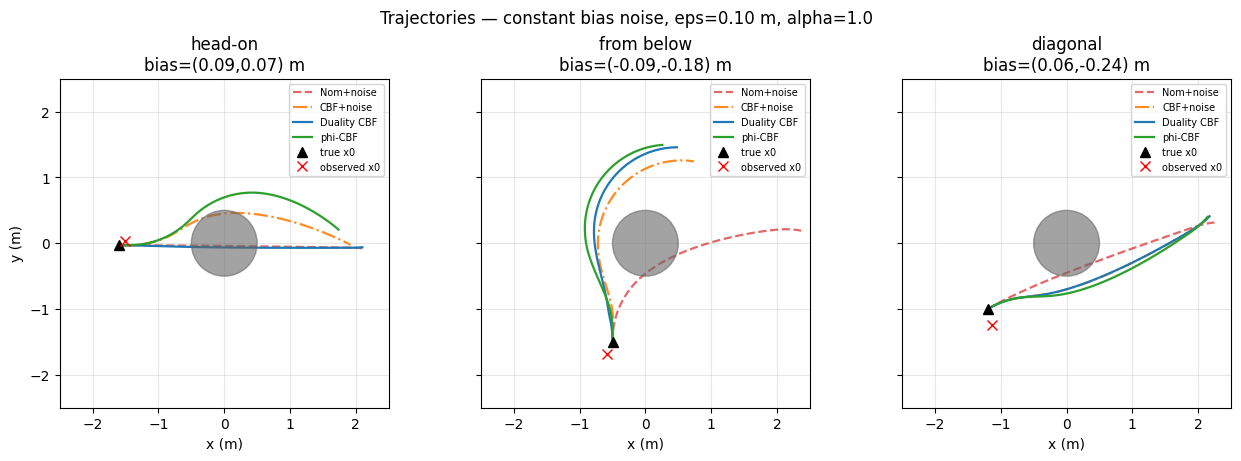

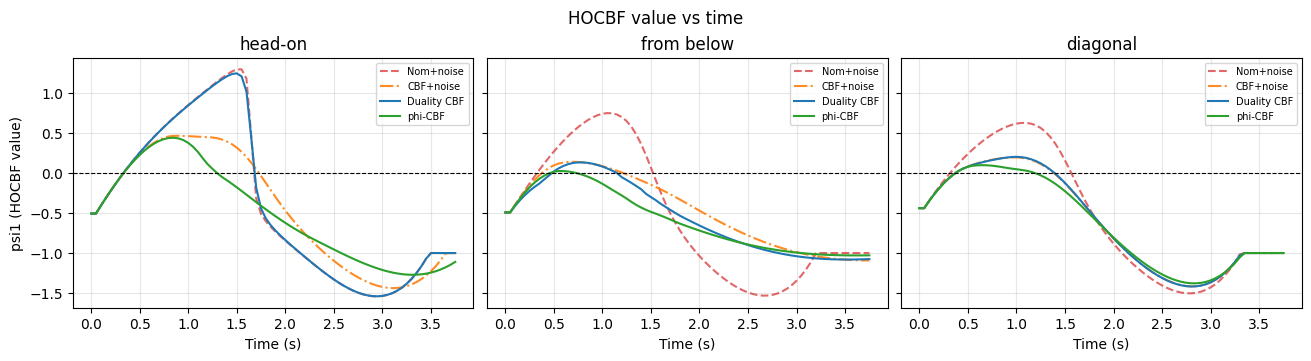

In [48]:
# ── Sample one fixed bias per IC (same bias for all three policies on each IC)
bias_per_ic = {
    name: _sample_bias(jax.random.fold_in(BASE_KEY, i))
    for i, name in enumerate(x_ics.keys())
}

pol_styles = [
    ('Nom+noise',   rollout_nom_noisy, '--', 'C3', 0.7),
    ('CBF+noise',   rollout_cbf_noisy, '-.',  'C1', 0.9),
    # ('R-CBF-QP',    rollout_rcbf,      ':',   'C4', 1.0),
    ('Duality CBF', rollout_duality,   '-',   'C0', 1.0),
    ('phi-CBF',     rollout_phi_cbf,   '-',   'C2', 1.0),
    # ('phi+RCBF',    rollout_phi_rcbf,  '-',   'C5', 1.0),
]

fig_traj, axes_traj = plt.subplots(1, 3, figsize=(13, 4.5), layout='constrained', sharey=True)
fig_cbf,  axes_cbf  = plt.subplots(1, 3, figsize=(13, 3.5), layout='constrained', sharey=True)
t_arr  = np.arange(T + 1) * DT
h_vmap = jax.jit(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha)))

trajs = {}
for ax_t, ax_c, (ic_name, x0), ic_col in zip(axes_traj, axes_cbf, x_ics.items(), colors):
    bias = bias_per_ic[ic_name]
    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.4', alpha=0.6, zorder=3)
    ax_t.add_patch(obs_p)
    for pol_name, rollout_fn, ls, col, alpha in pol_styles:
        xs_full, xhats = jax2np(rollout_fn(jnp.array(x0), bias))
        trajs[(ic_name, pol_name)] = xs_full
        ax_t.plot(xs_full[:, 0], xs_full[:, 1], ls=ls, color=col, lw=1.6, alpha=alpha, label=pol_name)
        psi1 = jax2np(h_vmap(jnp.array(xs_full)))[:, 0]
        ax_c.plot(t_arr, psi1, ls=ls, color=col, lw=1.5, alpha=alpha, label=pol_name)
    # Show the biased estimate offset
    x0_hat = jnp.array(x0) + bias
    ax_t.plot(*jnp.array(x0)[:2], 'k^', ms=7, zorder=5, label='true x0')
    ax_t.plot(*x0_hat[:2], 'rx',   ms=7, zorder=5, label='observed x0')
    ax_t.set(xlim=(-2.5, 2.5), ylim=(-2.5, 2.5), aspect='equal',
             xlabel='x (m)', title=f'{ic_name}\nbias=({float(bias[0]):.2f},{float(bias[1]):.2f}) m')
    ax_t.legend(fontsize=7); ax_t.grid(alpha=0.3)
    ax_c.axhline(0, color='k', lw=0.8, ls='--')
    ax_c.set(xlabel='Time (s)', title=ic_name)
    ax_c.legend(fontsize=7); ax_c.grid(alpha=0.3)
axes_traj[0].set_ylabel('y (m)')
axes_cbf[0].set_ylabel('psi1 (HOCBF value)')
fig_traj.suptitle(f'Trajectories — constant bias noise, eps={float(STATE_EPS_DUAL[0]):.2f} m, alpha={hocbf_alpha}')
fig_cbf.suptitle('HOCBF value vs time')
plt.show()


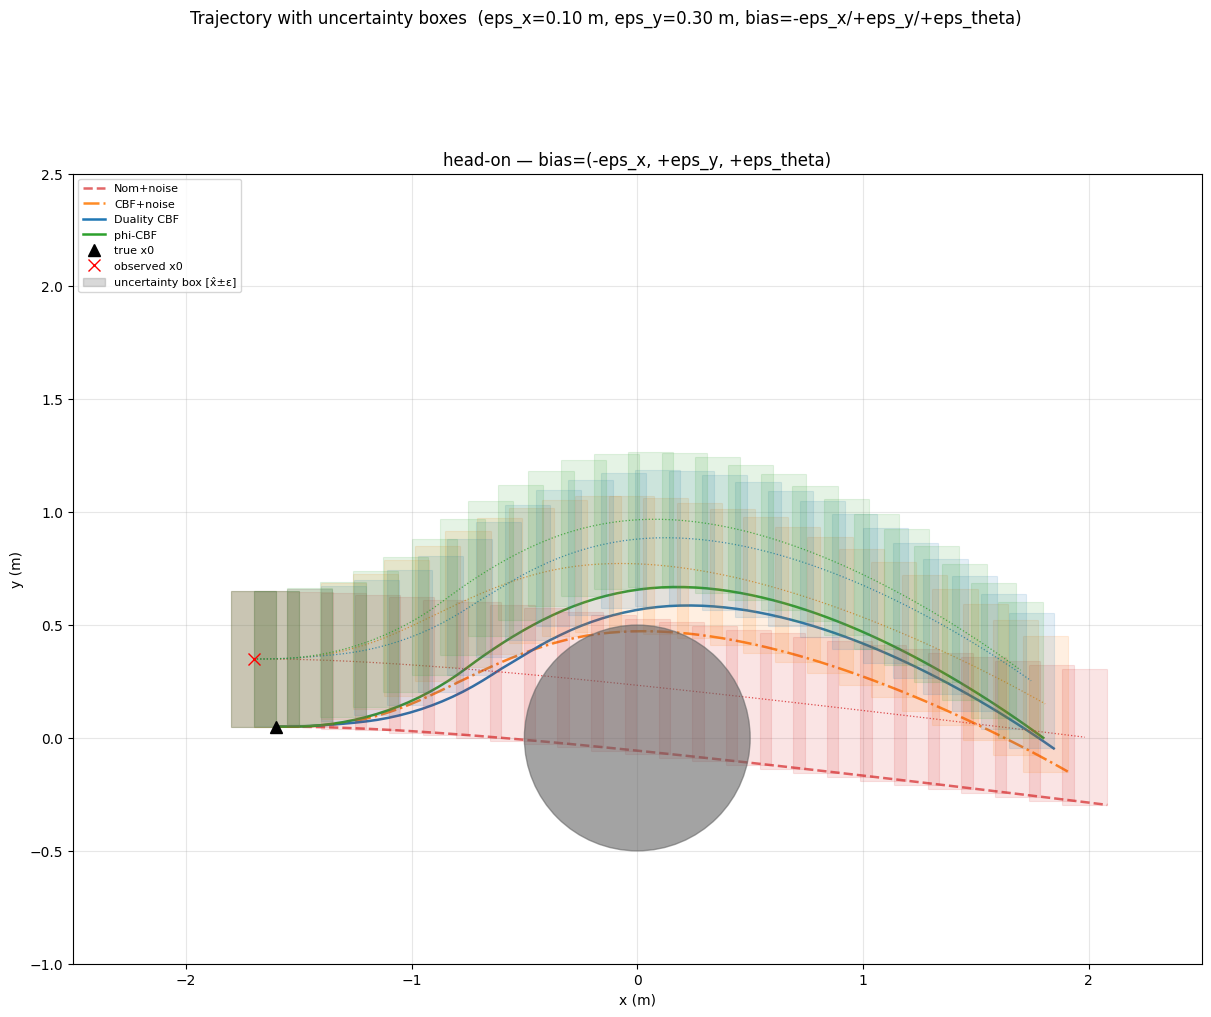

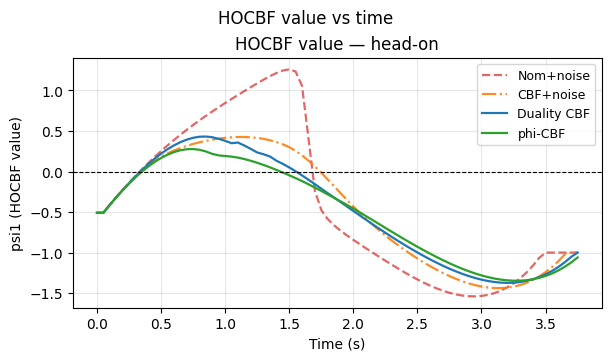

In [49]:
# Use only the first IC in x_ics
ic_name = next(iter(x_ics))
# x0 = x_ics[ic_name]
x0 = x_ics['head-on+']

# Fixed bias at maximum noise in the [-x, +y, +theta] direction
bias    = jnp.array([-STATE_EPS_DUAL[0], STATE_EPS_DUAL[1], STATE_EPS_DUAL[2]*0.0])
bias_np = jax2np(bias)

fig_traj, ax_t = plt.subplots(1, 1, figsize=(12, 11), layout='constrained')
fig_cbf,  ax_c = plt.subplots(1, 1, figsize=(6.0, 3.5), layout='constrained')

t_arr  = np.arange(T + 1) * DT
h_vmap = jax.jit(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha)))

trajs = {}
obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                   task.radius_obs, color='0.4', alpha=0.6, zorder=3)
ax_t.add_patch(obs_p)

for pol_name, rollout_fn, ls, col, alpha in pol_styles:
    xs_full, _ = jax2np(rollout_fn(jnp.array(x0), bias))
    trajs[(ic_name, pol_name)] = xs_full

    ax_t.plot(xs_full[:, 0], xs_full[:, 1], ls=ls, color=col, lw=1.8, alpha=alpha, label=pol_name)

    psi1 = jax2np(h_vmap(jnp.array(xs_full)))[:, 0]
    ax_c.plot(t_arr, psi1, ls=ls, color=col, lw=1.6, alpha=alpha, label=pol_name)

# ── Uncertainty boxes: centred on xhat = x_true + bias ───────────────────────
STRIDE = max(1, T // 20)
ex = float(STATE_EPS_DUAL[0])
ey = float(STATE_EPS_DUAL[1])

for pol_name, _, ls, col, _ in pol_styles:
    xs_full   = trajs[(ic_name, pol_name)]
    xhat_traj = xs_full + bias_np[None, :]
    ax_t.plot(xhat_traj[:, 0], xhat_traj[:, 1],
              ls=':', color=col, lw=0.9, alpha=0.8, zorder=2)
    for t in range(0, len(xs_full), STRIDE):
        cx = xhat_traj[t, 0]
        cy = xhat_traj[t, 1]
        rect = mpatches.Rectangle(
            (cx - ex, cy - ey), 2*ex, 2*ey,
            linewidth=0.8, edgecolor=col, facecolor=col,
            alpha=0.12, zorder=2
        )
        ax_t.add_patch(rect)

# IC markers
x0_hat = jnp.array(x0) + bias
ax_t.plot(*jnp.array(x0)[:2], 'k^', ms=8, zorder=6, label='true x0')
ax_t.plot(*jax2np(x0_hat)[:2], 'rx', ms=8, zorder=6, label='observed x0')

ax_t.set(
    xlim=(-2.5, 2.5), ylim=(-1.0, 2.5), aspect='equal',
    xlabel='x (m)', ylabel='y (m)',
    title=f'{ic_name} — bias=(-eps_x, +eps_y, +eps_theta)'
)
ax_t.legend(fontsize=9, loc='upper left')
ax_t.grid(alpha=0.3)

from matplotlib.patches import Patch
extra = [Patch(facecolor='gray', edgecolor='gray', alpha=0.3, label='uncertainty box [x̂±ε]')]
handles, labels = ax_t.get_legend_handles_labels()
ax_t.legend(handles + extra, labels + ['uncertainty box [x̂±ε]'], fontsize=8, loc='upper left')

ax_c.axhline(0, color='k', lw=0.8, ls='--')
ax_c.set(xlabel='Time (s)', ylabel='psi1 (HOCBF value)', title=f'HOCBF value — {ic_name}')
ax_c.legend(fontsize=9, loc='upper right')
ax_c.grid(alpha=0.3)

fig_traj.suptitle(f'Trajectory with uncertainty boxes  (eps_x={ex:.2f} m, eps_y={ey:.2f} m, bias=-eps_x/+eps_y/+eps_theta)')
fig_cbf.suptitle('HOCBF value vs time')
plt.show()


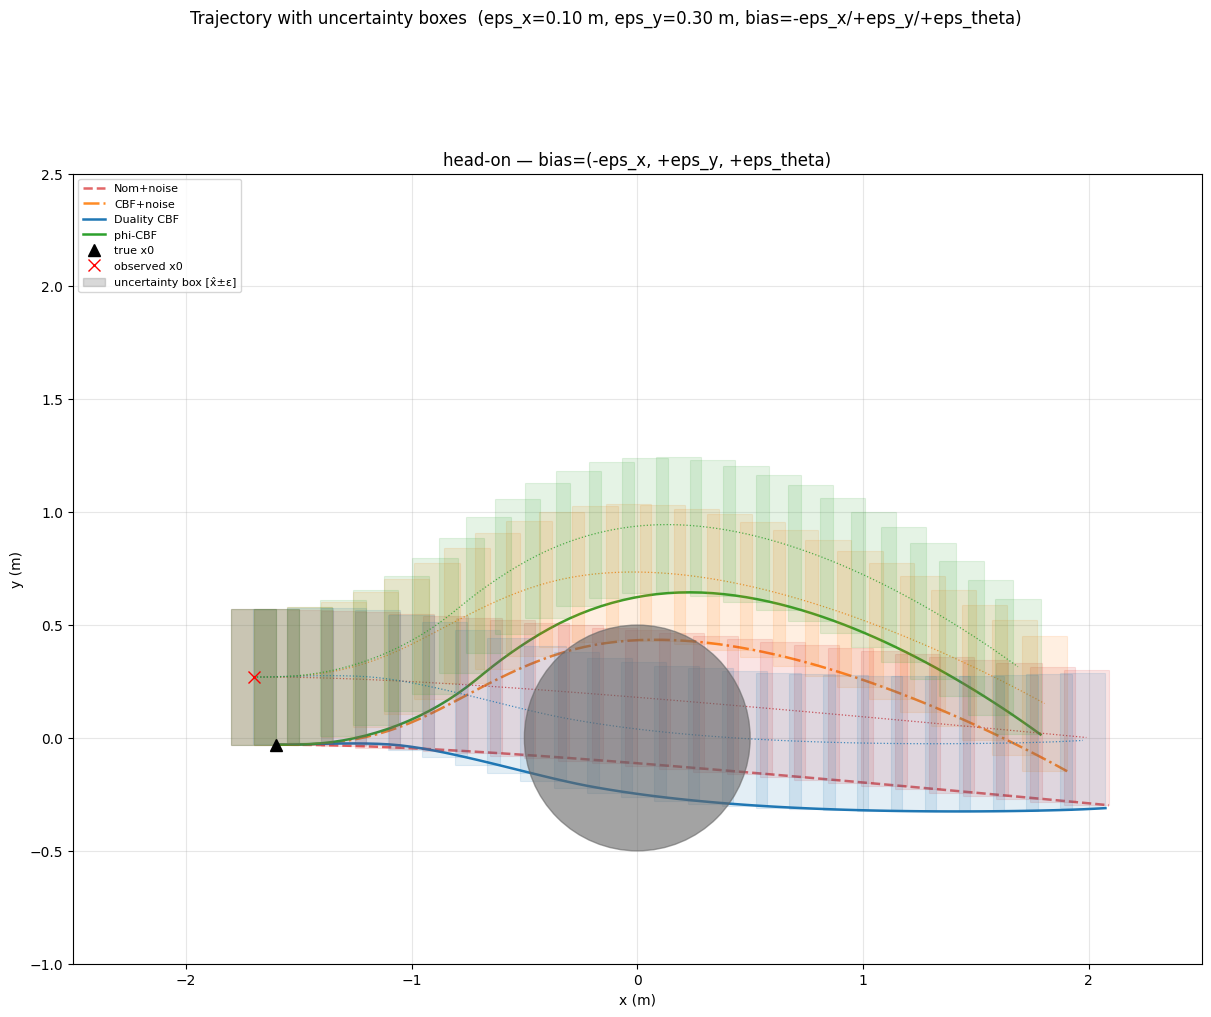

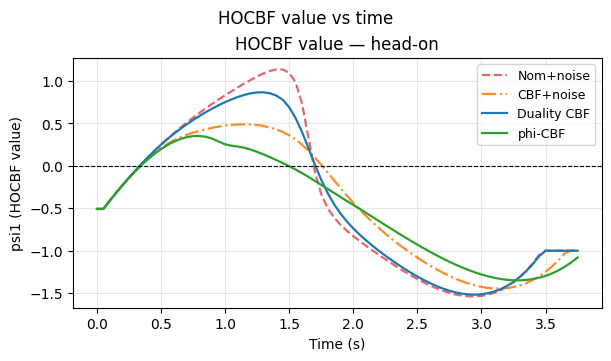

In [50]:
# Use only the first IC in x_ics
ic_name = next(iter(x_ics))
x0 = x_ics[ic_name]
# x0 = x_ics['head-on+']

# Fixed bias at maximum noise in the [-x, +y, +theta] direction
bias    = jnp.array([-STATE_EPS_DUAL[0], STATE_EPS_DUAL[1], STATE_EPS_DUAL[2]*0.0])
bias_np = jax2np(bias)

fig_traj, ax_t = plt.subplots(1, 1, figsize=(12, 11), layout='constrained')
fig_cbf,  ax_c = plt.subplots(1, 1, figsize=(6.0, 3.5), layout='constrained')

t_arr  = np.arange(T + 1) * DT
h_vmap = jax.jit(jax.vmap(lambda xi: task.handcbf_B(xi, hocbf_alpha)))

trajs = {}
obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                   task.radius_obs, color='0.4', alpha=0.6, zorder=3)
ax_t.add_patch(obs_p)

for pol_name, rollout_fn, ls, col, alpha in pol_styles:
    xs_full, _ = jax2np(rollout_fn(jnp.array(x0), bias))
    trajs[(ic_name, pol_name)] = xs_full

    ax_t.plot(xs_full[:, 0], xs_full[:, 1], ls=ls, color=col, lw=1.8, alpha=alpha, label=pol_name)

    psi1 = jax2np(h_vmap(jnp.array(xs_full)))[:, 0]
    ax_c.plot(t_arr, psi1, ls=ls, color=col, lw=1.6, alpha=alpha, label=pol_name)

# ── Uncertainty boxes: centred on xhat = x_true + bias ───────────────────────
STRIDE = max(1, T // 20)
ex = float(STATE_EPS_DUAL[0])
ey = float(STATE_EPS_DUAL[1])

for pol_name, _, ls, col, _ in pol_styles:
    xs_full   = trajs[(ic_name, pol_name)]
    xhat_traj = xs_full + bias_np[None, :]
    ax_t.plot(xhat_traj[:, 0], xhat_traj[:, 1],
              ls=':', color=col, lw=0.9, alpha=0.8, zorder=2)
    for t in range(0, len(xs_full), STRIDE):
        cx = xhat_traj[t, 0]
        cy = xhat_traj[t, 1]
        rect = mpatches.Rectangle(
            (cx - ex, cy - ey), 2*ex, 2*ey,
            linewidth=0.8, edgecolor=col, facecolor=col,
            alpha=0.12, zorder=2
        )
        ax_t.add_patch(rect)

# IC markers
x0_hat = jnp.array(x0) + bias
ax_t.plot(*jnp.array(x0)[:2], 'k^', ms=8, zorder=6, label='true x0')
ax_t.plot(*jax2np(x0_hat)[:2], 'rx', ms=8, zorder=6, label='observed x0')

ax_t.set(
    xlim=(-2.5, 2.5), ylim=(-1.0, 2.5), aspect='equal',
    xlabel='x (m)', ylabel='y (m)',
    title=f'{ic_name} — bias=(-eps_x, +eps_y, +eps_theta)'
)
ax_t.legend(fontsize=9, loc='upper left')
ax_t.grid(alpha=0.3)

from matplotlib.patches import Patch
extra = [Patch(facecolor='gray', edgecolor='gray', alpha=0.3, label='uncertainty box [x̂±ε]')]
handles, labels = ax_t.get_legend_handles_labels()
ax_t.legend(handles + extra, labels + ['uncertainty box [x̂±ε]'], fontsize=8, loc='upper left')

ax_c.axhline(0, color='k', lw=0.8, ls='--')
ax_c.set(xlabel='Time (s)', ylabel='psi1 (HOCBF value)', title=f'HOCBF value — {ic_name}')
ax_c.legend(fontsize=9, loc='upper right')
ax_c.grid(alpha=0.3)

fig_traj.suptitle(f'Trajectory with uncertainty boxes  (eps_x={ex:.2f} m, eps_y={ey:.2f} m, bias=-eps_x/+eps_y/+eps_theta)')
fig_cbf.suptitle('HOCBF value vs time')
plt.show()


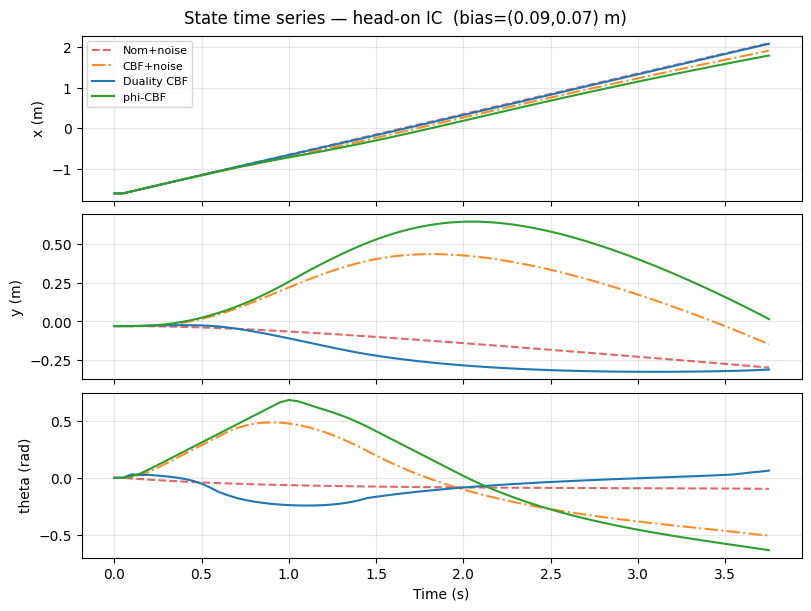

In [51]:
# ── State time series for head-on IC ─────────────────────────────────────────
ic_name = 'head-on'
x0_ho   = jnp.array(x_ics[ic_name])
bias_ho = bias_per_ic[ic_name]
state_labels = ['x (m)', 'y (m)', 'theta (rad)']

fig, axes = plt.subplots(3, 1, figsize=(8, 6), layout='constrained', sharex=True)
for pol_name, rollout_fn, ls, col, alpha in pol_styles:
    xs_full = trajs[(ic_name, pol_name)]
    for ax, s_label, si in zip(axes, state_labels, range(3)):
        ax.plot(t_arr, xs_full[:, si], ls=ls, color=col, lw=1.5, alpha=alpha, label=pol_name)
for ax, s_label in zip(axes, state_labels):
    ax.set_ylabel(s_label); ax.grid(alpha=0.3)
    if s_label == 'x (m)':
        ax.legend(fontsize=8)
axes[-1].set_xlabel('Time (s)')
fig.suptitle(f'State time series — {ic_name} IC  (bias=({float(bias_ho[0]):.2f},{float(bias_ho[1]):.2f}) m)')
plt.show()


## Monte Carlo safety evaluation (N = 1000)

Sample initial conditions uniformly from a region approaching the obstacle, filter to those inside the CBF-invariant set (`handcbf_B(x0) < 0`), and check **true** safety (`h_components > 0` at any timestep = collision).

Candidates: 1500000
  outside obstacle:       1500000  (100.0%)
  inside CBF set (psi<0): 750882  (50.1%)
  both (usable):          750882  (50.1%)
Using 100000 ICs: outside obstacle AND handcbf_B < 0
Bias stats: mean=0.067 m,  max=0.300 m
Compiling + running Monte Carlo rollouts...
  Nom+noise done.
  CBF+noise done.
  R-CBF-QP done.
  Duality CBF done.
  phi-CBF done.
Evaluating safety...
  Nom+noise       99784/100000   99.8%  95% CI [99.8%, 99.8%]
  CBF+noise       16699/100000   16.7%  95% CI [16.5%, 16.9%]
  R-CBF-QP        3954/100000    4.0%  95% CI [3.8%, 4.1%]
  Duality CBF     47714/100000   47.7%  95% CI [47.4%, 48.0%]
  phi-CBF         4044/100000    4.0%  95% CI [3.9%, 4.2%]


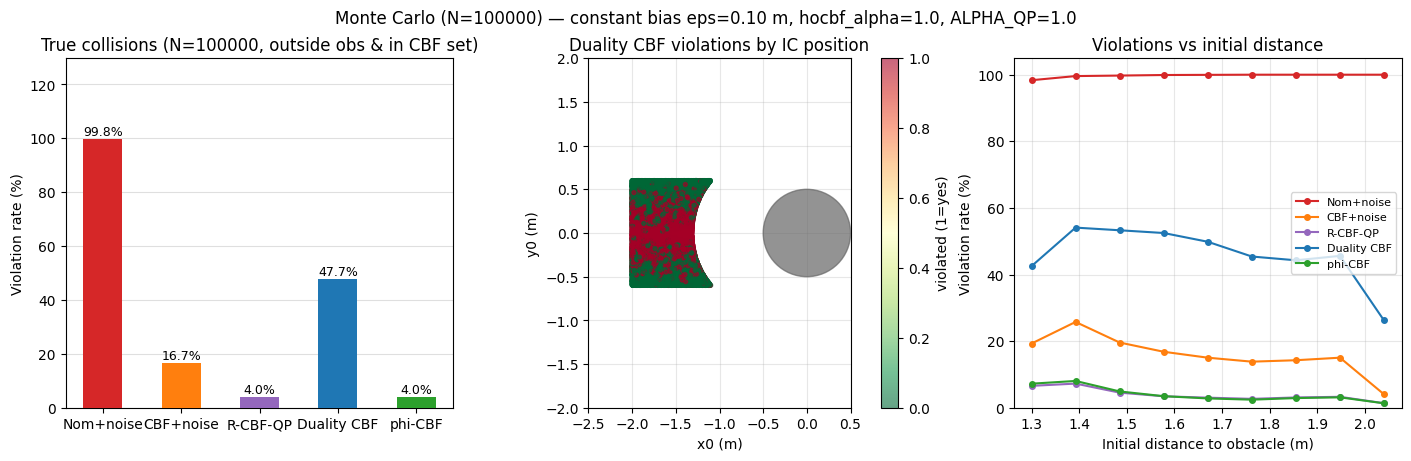

In [52]:
# ── Sample candidates ─────────────────────────────────────────────────────────
N_MC   = 100000
N_CAND = 1_500_000
rng_mc = np.random.default_rng(42)

# Approach from the left half-plane with varied heading
px_cand    = rng_mc.uniform(-2.0, -0.5, N_CAND)
py_cand    = rng_mc.uniform(-0.6, 0.6, N_CAND)
theta_cand = rng_mc.uniform(-np.pi/600, np.pi/600, N_CAND)

x0s_cand = jnp.array(np.stack([px_cand, py_cand, theta_cand], axis=1), dtype=jnp.float32)

# ── Filter: (1) outside obstacle  AND  (2) inside CBF-invariant set ──────────
h0_cand = jax2np(jax.vmap(task.h_components)(x0s_cand))
B0_cand = jax2np(jax.vmap(task.handcbf_B, in_axes=(0, None))(x0s_cand, hocbf_alpha))

outside_obs = h0_cand.max(axis=1) < 0
in_cbf_set  = B0_cand.max(axis=1) < 0
safe_mask   = outside_obs & in_cbf_set

n_safe = safe_mask.sum()
print(f"Candidates: {N_CAND}")
print(f"  outside obstacle:       {outside_obs.sum():5}  ({100*outside_obs.mean():.1f}%)")
print(f"  inside CBF set (psi<0): {in_cbf_set.sum():5}  ({100*in_cbf_set.mean():.1f}%)")
print(f"  both (usable):          {n_safe:5}  ({100*n_safe/N_CAND:.1f}%)")
assert n_safe >= N_MC, f"Too few safe ICs ({n_safe}); increase N_CAND."

safe_idx = np.where(safe_mask)[0][:N_MC]
x0s_mc   = x0s_cand[safe_idx]
px_mc    = px_cand[safe_idx]
py_mc    = py_cand[safe_idx]
print(f"Using {N_MC} ICs: outside obstacle AND handcbf_B < 0")

# ── Sample one independent bias per trajectory ────────────────────────────────
bias_keys = jax.random.split(jax.random.PRNGKey(99), N_MC)
mc_biases = jax.vmap(_sample_bias)(bias_keys)   # (N_MC, nx)
print(f"Bias stats: mean={float(jnp.abs(mc_biases).mean()):.3f} m,  "
      f"max={float(jnp.abs(mc_biases).max()):.3f} m")

# ── Run MC rollouts ───────────────────────────────────────────────────────────
mc_rollout_nom     = jax.jit(jax.vmap(rollout_nom_noisy))
mc_rollout_cbf     = jax.jit(jax.vmap(rollout_cbf_noisy))
mc_rollout_rcbf    = jax.jit(jax.vmap(rollout_rcbf))
mc_rollout_duality = jax.jit(jax.vmap(rollout_duality))
mc_rollout_phi     = jax.jit(jax.vmap(rollout_phi_cbf))
# mc_rollout_phi_rcbf = jax.jit(jax.vmap(rollout_phi_rcbf))

print("Compiling + running Monte Carlo rollouts...")
mc_trajs = {}
for pol_name, mc_fn in [('Nom+noise',   mc_rollout_nom),
                         ('CBF+noise',   mc_rollout_cbf),
                         ('R-CBF-QP',    mc_rollout_rcbf),
                         ('Duality CBF', mc_rollout_duality),
                         ('phi-CBF',     mc_rollout_phi),
                        #  ('phi+RCBF',    mc_rollout_phi_rcbf)
                         ]:
    xs_all, _ = jax2np(mc_fn(x0s_mc, mc_biases))   # (N_MC, T+1, nx)
    mc_trajs[pol_name] = xs_all
    print(f"  {pol_name} done.")

# ── True safety check ─────────────────────────────────────────────────────────
print("Evaluating safety...")
h_vmap_mc = jax.jit(jax.vmap(jax.vmap(task.h_components)))

mc_results = {}
for pol_name, xs_all in mc_trajs.items():
    h_all    = jax2np(h_vmap_mc(jnp.array(xs_all)))
    violated = h_all.max(axis=(1, 2)) > 0
    mc_results[pol_name] = violated
    n_viol = violated.sum()
    rate   = n_viol / N_MC
    z      = 1.96
    lo_ci = (rate + z**2/(2*N_MC) - z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
    hi_ci = (rate + z**2/(2*N_MC) + z*np.sqrt(rate*(1-rate)/N_MC + z**2/(4*N_MC**2))) / (1 + z**2/N_MC)
    print(f"  {pol_name:<14}  {n_viol:4}/{N_MC}  {100*rate:5.1f}%  "
          f"95% CI [{100*lo_ci:.1f}%, {100*hi_ci:.1f}%]")

# ── Plots ─────────────────────────────────────────────────────────────────────
pol_names  = list(mc_results.keys())
pol_colors = ['C3', 'C1', 'C4', 'C0', 'C2', 'C5']
rates = [mc_results[n].mean() for n in pol_names]

fig, axes = plt.subplots(1, 3, figsize=(14, 4.5), layout='constrained')

axes[0].bar(pol_names, [100*r for r in rates], color=pol_colors, width=0.5, zorder=3)
axes[0].set(ylabel='Violation rate (%)',
            title=f'True collisions (N={N_MC}, outside obs & in CBF set)')
axes[0].set_ylim(0, max(100*max(rates)*1.3, 3))
axes[0].grid(axis='y', alpha=0.4, zorder=0)
for i, r in enumerate(rates):
    axes[0].text(i, 100*r + 0.15, f'{100*r:.1f}%', ha='center', va='bottom', fontsize=9)

viol_dual = mc_results['Duality CBF'].astype(float)
obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                    task.radius_obs, color='0.4', alpha=0.7, zorder=4)
axes[1].add_patch(obs_p)
sc = axes[1].scatter(px_mc, py_mc, c=viol_dual, cmap='RdYlGn_r', vmin=0, vmax=1,
                     s=8, alpha=0.6, zorder=3)
plt.colorbar(sc, ax=axes[1], label='violated (1=yes)')
axes[1].set(xlabel='x0 (m)', ylabel='y0 (m)', aspect='equal',
            xlim=(-2.5, 0.5), ylim=(-2.0, 2.0),
            title='Duality CBF violations by IC position')
axes[1].grid(alpha=0.3)

dist_mc = np.sqrt(px_mc**2 + py_mc**2)
bins = np.linspace(dist_mc.min(), dist_mc.max(), 10)
bin_centers = 0.5*(bins[:-1] + bins[1:])
bin_idx_arr = np.digitize(dist_mc, bins) - 1
for pol_name, col in zip(pol_names, pol_colors):
    viol = mc_results[pol_name].astype(float)
    bin_rate = [viol[bin_idx_arr == b].mean() if (bin_idx_arr == b).any() else np.nan
                for b in range(len(bins)-1)]
    axes[2].plot(bin_centers, [100*r for r in bin_rate],
                 color=col, marker='o', ms=4, lw=1.5, label=pol_name)
axes[2].set(xlabel='Initial distance to obstacle (m)', ylabel='Violation rate (%)',
            title='Violations vs initial distance')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)
axes[2].set_ylim(bottom=0)

fig.suptitle(f'Monte Carlo (N={N_MC}) — constant bias eps={float(STATE_EPS_DUAL[0]):.2f} m, '
             f'hocbf_alpha={hocbf_alpha}, ALPHA_QP={ALPHA_QP}')
plt.show()


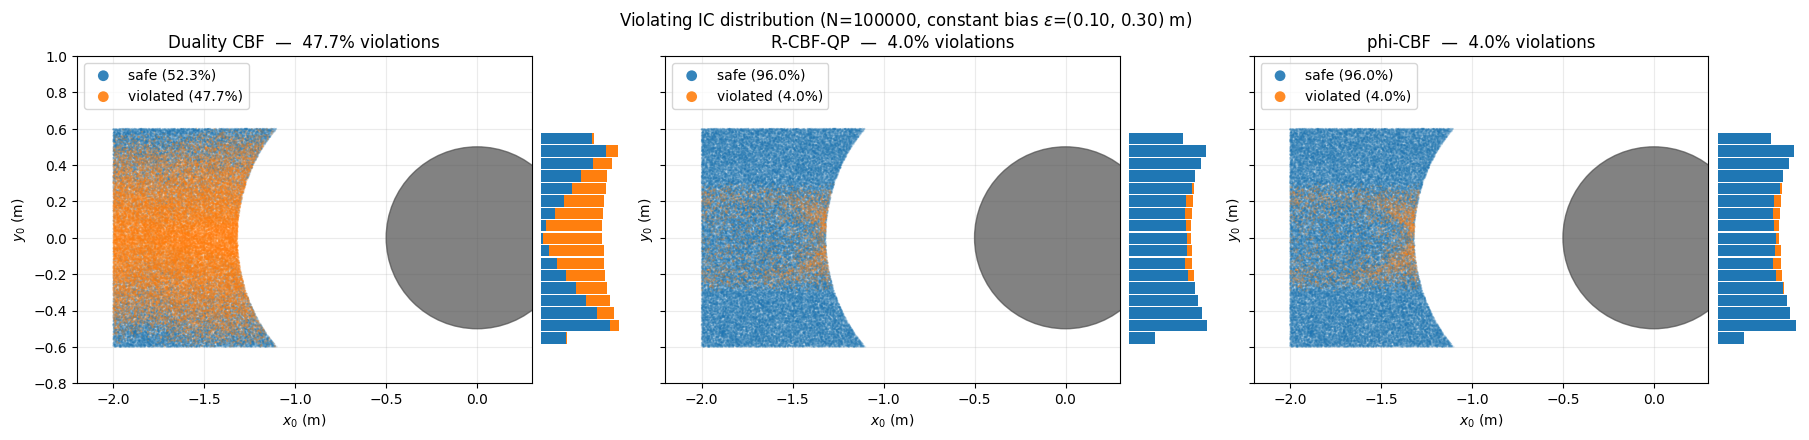

In [53]:
# ── Violation IC distribution: Duality CBF vs phi-CBF ────────────────────────
# focus_pols = ['Duality CBF', 'phi-CBF', 'phi+RCBF']
focus_pols = ['Duality CBF', 'R-CBF-QP', 'phi-CBF']
focus_cols = ['C0', 'C2', 'C5']

fig, axes = plt.subplots(1, 3, figsize=(18, 6), layout='constrained',
                         sharex=True, sharey=True)

for ax, pol_name, col in zip(axes, focus_pols, focus_cols):
    viol = mc_results[pol_name]          # (N_MC,) bool
    n_viol = viol.sum()
    rate   = viol.mean()
    # Safe ICs (blue) — plot first so violations sit on top
    safe_col = 'C0'   # tab10 blue
    viol_col = 'C1'   # tab10 orange

    ax.scatter(px_mc[~viol], py_mc[~viol],
               c=safe_col, edgecolors='none', s=2, alpha=0.15,
               zorder=2, label=f'safe ({100*(1-rate):.1f}%)')
    # Violating ICs (orange)
    if n_viol > 0:
        ax.scatter(px_mc[viol], py_mc[viol],
                   c=viol_col, edgecolors='none', s=2, alpha=0.2,
                   zorder=3, label=f'violated ({100*rate:.1f}%)')

    # Obstacle
    obs_p = plt.Circle((float(task.pos_obs[0]), float(task.pos_obs[1])),
                        task.radius_obs, color='0.3', alpha=0.7, zorder=4)
    ax.add_patch(obs_p)

    ax.set(xlim=(-2.2, 0.3), ylim=(-0.8, 1.0), aspect='equal',
           xlabel='$x_0$ (m)', ylabel='$y_0$ (m)',
           title=f'{pol_name}  —  {100*rate:.1f}% violations')
    leg = ax.legend(fontsize=10, loc='upper left')
    for h in leg.legend_handles:
        h.set_sizes([60])
        h.set_alpha(0.9)
    ax.grid(alpha=0.25)

    # Marginal histograms — stacked so safe/violated bars sit on top of each other
    # ax_top   = ax.inset_axes([0, 1.02, 1, 0.18])
    ax_right = ax.inset_axes([1.02, 0, 0.18, 1])
    bins_x = np.linspace(-2.2, 0.3, 25)
    bins_y = np.linspace(-0.8, 1.0, 25)

    # ax_top.hist([px_mc[~viol], px_mc[viol]], bins=bins_x,
    #             color=[safe_col, viol_col], stacked=True, rwidth=0.9)
    # ax_top.axis('off')

    ax_right.hist([py_mc[~viol], py_mc[viol]], bins=bins_y,
                  color=[safe_col, viol_col], stacked=True,
                  orientation='horizontal', rwidth=0.9)
    ax_right.axis('off')

fig.suptitle(
    f'Violating IC distribution (N={N_MC}, constant bias $\\varepsilon$='
    f'({float(STATE_EPS_DUAL[0]):.2f}, {float(STATE_EPS_DUAL[1]):.2f}) m)',
    y=0.85
)
plt.show()


## Timing

Per-step compute time for each policy.

  Nom+noise       0.8 ms ± 0.1 ms  (0.011 ms/step)
  CBF+noise       31.8 ms ± 2.3 ms  (0.424 ms/step)
  R-CBF-QP        35.6 ms ± 0.1 ms  (0.474 ms/step)
  Duality CBF     68.2 ms ± 0.1 ms  (0.909 ms/step)
  phi-CBF         30.1 ms ± 0.7 ms  (0.401 ms/step)


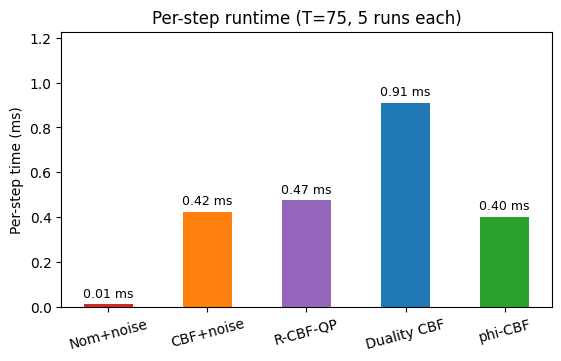

In [54]:
import time

x_time    = jnp.array(list(x_ics.values())[0])
bias_time = _sample_bias(BASE_KEY)

# Pre-compile all policies
for fn in [rollout_nom_noisy, rollout_cbf_noisy, rollout_rcbf, rollout_duality, rollout_phi_cbf]:
    fn(x_time, bias_time)

N_REPEATS = 5
timing = {}
for pol_name, rollout_fn in [('Nom+noise',   rollout_nom_noisy),
                              ('CBF+noise',   rollout_cbf_noisy),
                              ('R-CBF-QP',    rollout_rcbf),
                              ('Duality CBF', rollout_duality),
                              ('phi-CBF',     rollout_phi_cbf),
                            #   ('phi+RCBF',    rollout_phi_rcbf)
                              ]:
    times = []
    for _ in range(N_REPEATS):
        t0 = time.perf_counter()
        jax.block_until_ready(rollout_fn(x_time, bias_time))
        times.append(time.perf_counter() - t0)
    timing[pol_name] = times
    print(f'  {pol_name:<14}  {np.mean(times)*1e3:.1f} ms ± {np.std(times)*1e3:.1f} ms'
          f'  ({np.mean(times)/T*1e3:.3f} ms/step)')

names    = list(timing.keys())
per_step = [1e3 * np.mean(v) / T for v in timing.values()]
pol_cols = ['C3', 'C1', 'C4', 'C0', 'C2', 'C5']   # matches pol_styles

fig, ax = plt.subplots(figsize=(5.5, 3.5), layout='constrained')
bars = ax.bar(names, per_step, color=pol_cols[:len(names)], width=0.5)
ax.bar_label(bars, labels=[f'{v:.2f} ms' for v in per_step], padding=3, fontsize=9)
ax.set(ylabel='Per-step time (ms)', ylim=(0, max(per_step) * 1.35),
       title=f'Per-step runtime (T={T}, {N_REPEATS} runs each)')
ax.tick_params(axis='x', labelrotation=15)
plt.show()
